交差検証を開始します

--- Fold 1 ---
--- Fold 2 ---
--- Fold 3 ---
--- Fold 4 ---
--- Fold 5 ---

LightGBM 交差検証
Balanced Accuracy: 0.94639



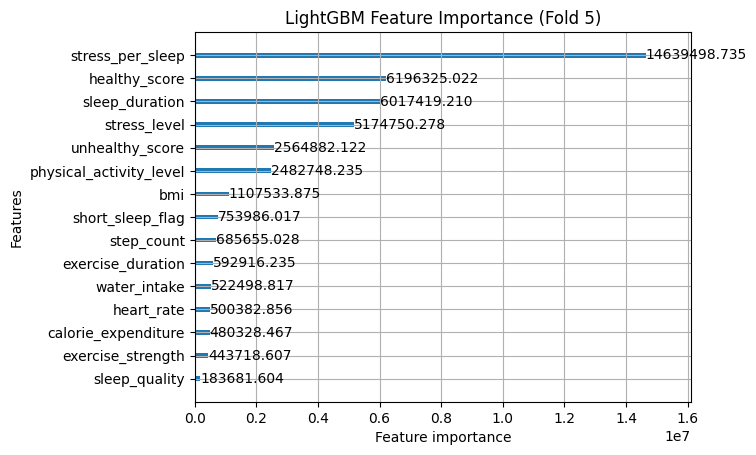


XGBoost  交差検証
Balanced Accuracy: 0.94928



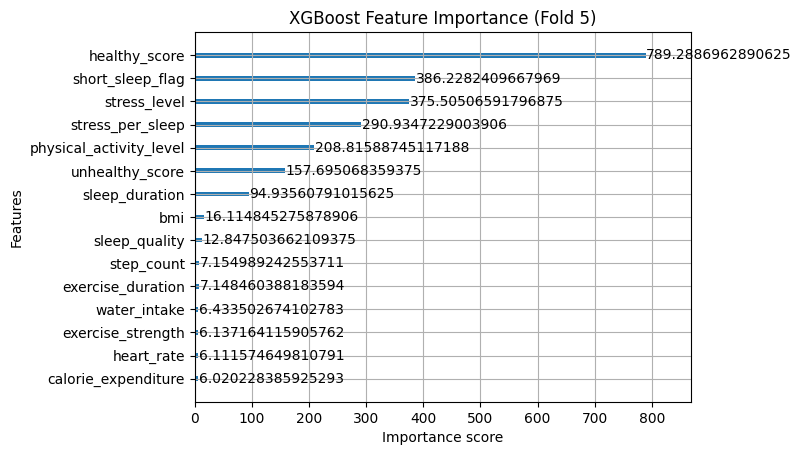


提出用ファイル 'submission_ensemble.csv' を作成しました☆



In [ ]:
#V1.3

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

def df_Data_Cleansing(df):
    cat_cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().astype('category')

    #14
    df['short_sleep_flag'] = (df['sleep_duration'] < 6.0).astype(int)

    #15
    df["exercise_strength"] = df['calorie_expenditure'] / ((df['exercise_duration'] + 0.1) * df['bmi'])

    #16
    df['healthy_score'] = (
        df['sleep_duration'].between(7, 8).astype(int) +
        (df['bmi'] <= 19).astype(int) +
        (df['exercise_duration'] >= 40).astype(int) +
        (df['stress_level'] == 'low').astype(int) +
        (df['sleep_quality'] == 'good').astype(int) +
        (df['physical_activity_level'] == 'active').astype(int)
    )

    #17
    df['unhealthy_score'] = (
        df['sleep_duration'].between(5, 6).astype(int) +
        (df['bmi'] >= 27).astype(int) +
        (df['calorie_expenditure'] <= 1400).astype(int) +
        (df['step_count'] <= 5000).astype(int) +
        (df['exercise_duration'] <= 30).astype(int) +
        (df['stress_level'] == 'high').astype(int) +
        (df['sleep_quality'] == 'poor').astype(int) +
        df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
        (df['smoking_alcohol'] == 'yes').astype(int)
    )

    #18
    stress_mapping = {'low': 1, 'medium': 2, 'high': 3}
    df['stress_level_num'] = df['stress_level'].map(stress_mapping).astype(float)
    df['stress_per_sleep'] = df['stress_level_num'] / df['sleep_duration']

    # 不要な特徴量をまとめて削除
    drop_cols = [
        'stress_level_num',
        'diet_type',
        'gender',
        'smoking_alcohol',
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    return df

#========
#読み込み
#df = df_Data_Cleansing(pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv',encoding="utf-8"))
#df_test = df_Data_Cleansing(pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv',encoding="utf-8"))

df = df_Data_Cleansing(pd.read_csv('/content/data/train.csv',encoding="utf-8"))
df_test = df_Data_Cleansing(pd.read_csv('/content/data/test.csv',encoding="utf-8"))



#特徴量(X)とターゲット(y)の分割
X = df.drop(['id', 'health_condition'], axis=1)
y = df['health_condition']

# stress_levelのラベルエンコーディング
le_stress = LabelEncoder()
X['stress_level'] = le_stress.fit_transform(X['stress_level'])
df_test['stress_level'] = le_stress.transform(df_test['stress_level'])

# 【変更点】補完対象の数値カラムをリスト化（補完処理自体はFoldループ内で実行）
NUMS = X.select_dtypes(include="float").columns.tolist() + X.select_dtypes(include="int").columns.tolist()

#ターゲット(y)を数値に変換
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 提出用データの準備
X_test = df_test.drop(['id'], axis=1)

# 交差検証の設定 (5分割)
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# 結果保存用の配列
lgb_oof_preds = np.zeros(len(X))
xgb_oof_preds = np.zeros(len(X))
lgb_test_probs = []
xgb_test_probs = []

print("=========================")
print("交差検証を開始します")
print("=========================\n")

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded)):
    print(f"--- Fold {fold + 1} ---")

    # .copy()をつけて警告を防ぐ
    X_train, y_train = X.iloc[train_idx].copy(), y_encoded[train_idx]
    X_valid, y_valid = X.iloc[valid_idx].copy(), y_encoded[valid_idx]
    X_test_fold = X_test.copy()

    # 【変更点】Fold内の学習データの中央値を計算し、Train/Valid/Testを補完（データリーク防止）
    train_medians = X_train[NUMS].median()
    X_train[NUMS] = X_train[NUMS].fillna(train_medians)
    X_valid[NUMS] = X_valid[NUMS].fillna(train_medians)
    X_test_fold[NUMS] = X_test_fold[NUMS].fillna(train_medians)

    sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

    # ========== LightGBM ==========
    model_lgb = lgb.LGBMClassifier(
        verbose=-1,
        class_weight='balanced',
        random_state=42,
        n_estimators=3000,
        learning_rate=0.013578512419982092,
        num_leaves=92,
        max_depth=9,
        min_child_samples=36,
        subsample=0.505217415288255,
        colsample_bytree=0.7581737202993579
    )
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    lgb_oof_preds[valid_idx] = model_lgb.predict(X_valid)
    lgb_test_probs.append(model_lgb.predict_proba(X_test_fold))

    # ========== XGBoost ==========
    model_xgb = xgb.XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        enable_categorical=True,
        learning_rate=0.029880659828276236,
        max_depth=5,
        min_child_weight=9,
        subsample=0.9527064742344795,
        colsample_bytree=0.8672601416983036,
        n_estimators=3000,
        early_stopping_rounds=50
    )
    model_xgb.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    xgb_oof_preds[valid_idx] = model_xgb.predict(X_valid)
    xgb_test_probs.append(model_xgb.predict_proba(X_test_fold))


# OOF予測スコアの計算と表示
score_lgb = balanced_accuracy_score(y_encoded, lgb_oof_preds)
score_xgb = balanced_accuracy_score(y_encoded, xgb_oof_preds)

# 特徴量重要度の表示（最後のFoldのモデルを使用）
print(f"""
=========================
LightGBM 交差検証
Balanced Accuracy: {score_lgb:.5f}
=========================
""")
lgb.plot_importance(model_lgb, max_num_features=20, importance_type='gain', title='LightGBM Feature Importance (Fold 5)')
plt.show()

print(f"""
=========================
XGBoost  交差検証
Balanced Accuracy: {score_xgb:.5f}
=========================
""")
xgb.plot_importance(model_xgb, max_num_features=20, importance_type='gain', title='XGBoost Feature Importance (Fold 5)')
plt.show()

# ========== アンサンブル予測 ==========
# 5つのモデルの予測確率を平均化
preds_prob_lgb_mean = np.mean(lgb_test_probs, axis=0)
preds_prob_xgb_mean = np.mean(xgb_test_probs, axis=0)

# 確率を均等にブレンド
blend_prob = (preds_prob_lgb_mean * 0.5) + (preds_prob_xgb_mean * 0.5)

# 最も確率が高いクラスを選択
final_preds = np.argmax(blend_prob, axis=1)

submission_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': submission_labels
})

submission.to_csv('submission_ensemble.csv', index=False)
X_test.head(100).to_csv("submit_x_x_x_x_x_x.csv", index=False)
print("""
=========================
提出用ファイル 'submission_ensemble.csv' を作成しました☆
=========================
""")